# Exportação SFT — conversas com feedback positivo

Exporta conversas até o **último** feedback 👍 (sem 👎 ou guardrail `blocked`/`regenerated` antes), com uma linha JSONL por chamada LLM:

- `generate` — par `llm_input` / `llm_output` do turno final
- auxiliares (`router`, `rewrite`, `guardrail_classify`, `guardrail_regenerate`) de `conversation_message_llm_calls`

Mensagens substituídas (`superseded_by_message_id`) são ignoradas. PII é substituída por valores sintéticos consistentes; blocos PCDT permanecem byte-a-byte.


In [26]:
import json
import sqlite3
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator
from datasets import load_dataset

try:
    from IPython.display import display
except ImportError:
    display = print  # noqa: A001

NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "assets").exists():
    FINE_TUNING_DIR = NOTEBOOK_DIR
else:
    FINE_TUNING_DIR = NOTEBOOK_DIR / "llm" / "fine-tuning"

REPO_ROOT = FINE_TUNING_DIR.parent.parent
SCRIPTS_DIR = REPO_ROOT / "llm" / "scripts"
sys.path.insert(0, str(SCRIPTS_DIR))

from chroma_llama_token_analysis import DEFAULT_HF_TOKENIZER_REPO, load_llama_tokenizer
from sft_anonymize import (
    ExportFunnel,
    ReplacementRegistry,
    anonymize_sft_text,
    assign_fake_name,
    build_clinical_allow_list,
    count_sft_tokens,
    pseudonymize_id,
    validate_anonymization,
)
from sft_export_positive import build_export_rows, evaluate_conversation


In [27]:
# Configuração
DB_PATH = REPO_ROOT / "backend" / "assistente_medico.db"
OUTPUT_PATH = FINE_TUNING_DIR / "assets" / "sft_positive_conversations.jsonl"
ANONYMIZATION_SALT = "sft-export-v1"
INCLUDE_ARCHIVED = True
TOKENIZER_BACKEND = "transformers"
REPLACE_FIRST_NAME_TOKEN = False

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
print("DB:", DB_PATH)
print("Saída:", OUTPUT_PATH)


DB: /Users/leanderseefeld/workspaces/fiap/8iadt-tc-fase3-assistente-medico/backend/assistente_medico.db
Saída: /Users/leanderseefeld/workspaces/fiap/8iadt-tc-fase3-assistente-medico/llm/fine-tuning/assets/sft_positive_conversations.jsonl


## Carregar mensagens ativas e chamadas auxiliares


In [28]:
arch_filter = "" if INCLUDE_ARCHIVED else "AND c.archived_at IS NULL"

conn = sqlite3.connect(DB_PATH)
messages_df = pd.read_sql_query(
    f"""
    SELECT m.*, c.patient_id, c.doctor_id, p.name AS patient_name
    FROM conversation_messages m
    JOIN conversations c ON c.id = m.conversation_id
    JOIN patients p ON p.id = c.patient_id
    WHERE m.superseded_by_message_id IS NULL
      {arch_filter}
    ORDER BY m.conversation_id, m.created_at ASC
    """,
    conn,
)
cid_df = pd.read_sql_query(
    """
    SELECT DISTINCT cid_label FROM patients
    WHERE cid_label IS NOT NULL AND cid_label != ''
    """,
    conn,
)

print(f"Conversas: {messages_df['conversation_id'].nunique()}")
print(f"Mensagens ativas: {len(messages_df)}")


Conversas: 23
Mensagens ativas: 84


## Truncamento e seleção do turno final


In [29]:
funnel = ExportFunnel(scanned=int(messages_df["conversation_id"].nunique()))
targets = []

for conv_id, group in messages_df.groupby("conversation_id"):
    target, drop_reason = evaluate_conversation(conv_id, group)
    if target is None:
        funnel.drop(drop_reason or "unknown")
    else:
        targets.append(target)

funnel.exported = len(targets)
final_message_ids = [t.message_id for t in targets]

if final_message_ids:
    placeholders = ",".join("?" * len(final_message_ids))
    aux_df = pd.read_sql_query(
        f"""
        SELECT * FROM conversation_message_llm_calls
        WHERE assistant_message_id IN ({placeholders})
        ORDER BY assistant_message_id, sequence ASC
        """,
        conn,
        params=final_message_ids,
    )
else:
    aux_df = pd.DataFrame()

conn.close()

raw_rows = build_export_rows(
    targets,
    aux_df,
    salt=ANONYMIZATION_SALT,
    pseudonymize_fn=pseudonymize_id,
)

print(f"Alvos exportáveis: {len(targets)}")
print(f"Linhas pré-anonimização: {len(raw_rows)}")
print("Descartes:", funnel.dropped)


Alvos exportáveis: 11
Linhas pré-anonimização: 69
Descartes: {'no_positive': 12}


## Fase 1 — allow-list clínica e registry


In [30]:
pcdt_texts = []
for row in raw_rows:
    if row["call_type"] != "generate":
        continue
    for msg in row["llm_input"]:
        pcdt_texts.append(str(msg.get("content") or ""))

fake_names = {
    t.patient_id: assign_fake_name(t.patient_id, ANONYMIZATION_SALT) for t in targets
}

clinical_allow_list = build_clinical_allow_list(
    pcdt_texts=pcdt_texts,
    patient_names=[t.patient_name for t in targets],
    fake_names=fake_names.values(),
    cid_labels=cid_df["cid_label"].tolist(),
)

registry = ReplacementRegistry(ANONYMIZATION_SALT)
print(f"Allow-list: {len(clinical_allow_list)} tokens")


Allow-list: 2876 tokens


## Fase 2 — anonimização e validação


In [31]:
by_conv: dict[str, list[dict]] = {}
for row in raw_rows:
    by_conv.setdefault(row["conversation_id"], []).append(row)

export_records: list[dict] = []
stats_rows: list[dict] = []

for conv_id, conv_rows in by_conv.items():
    generate_row = next(r for r in conv_rows if r["call_type"] == "generate")

    anon_in, anon_out, _ = anonymize_sft_text(
        generate_row["llm_input"],
        generate_row["llm_output"],
        registry=registry,
        fake_names=fake_names,
        allow_list=clinical_allow_list,
        patient_id=generate_row["_raw_patient_id"],
        patient_name=generate_row["_patient_name"],
        replace_first_token=REPLACE_FIRST_NAME_TOKEN,
    )
    ok, errors = validate_anonymization(
        llm_input=anon_in,
        llm_output=anon_out,
        original_llm_input=generate_row["llm_input"],
        original_llm_output=generate_row["llm_output"],
        patient_name=generate_row["_patient_name"],
        fake_name=fake_names.get(generate_row["_raw_patient_id"]),
    )
    if not ok:
        funnel.exported -= 1
        funnel.drop("pii_validation_failed")
        print(f"Validação falhou {conv_id}: {errors}")
        continue

    export_records.append({
        "conversation_id": generate_row["conversation_id"],
        "patient_id": generate_row["patient_id"],
        "doctor_id": generate_row["doctor_id"],
        "message_id": generate_row["message_id"],
        "call_type": "generate",
        "sequence": -1,
        "model": None,
        "llm_input": anon_in,
        "llm_output": anon_out,
    })
    stats_rows.append({
        "conversation_id": generate_row["conversation_id"],
        "message_count": generate_row["_message_count"],
        "turn_count": generate_row["_turn_count"],
        "call_type": "generate",
    })

    for r in conv_rows:
        if r["call_type"] == "generate":
            continue
        aux_in, aux_out, _ = anonymize_sft_text(
            r["llm_input"],
            r["llm_output"],
            registry=registry,
            fake_names=fake_names,
            allow_list=clinical_allow_list,
            patient_id=r["_raw_patient_id"],
            patient_name=r["_patient_name"],
            replace_first_token=REPLACE_FIRST_NAME_TOKEN,
        )
        export_records.append({
            "conversation_id": r["conversation_id"],
            "patient_id": r["patient_id"],
            "doctor_id": r["doctor_id"],
            "message_id": r["message_id"],
            "call_type": r["call_type"],
            "sequence": int(r["sequence"]),
            "model": r["model"],
            "llm_input": aux_in,
            "llm_output": aux_out,
        })
        stats_rows.append({
            "conversation_id": r["conversation_id"],
            "message_count": r["_message_count"],
            "turn_count": r["_turn_count"],
            "call_type": r["call_type"],
        })

df_export = pd.DataFrame(export_records)
df_stats = pd.DataFrame(stats_rows)
print(f"Linhas exportadas: {len(df_export)}")
print("Substituições PII:", dict(registry.counts))


Linhas exportadas: 69
Substituições PII: {}


## Tokens (Llama 3.2) e estatísticas


In [32]:
tokenizer, _count_fn, tokenizer_label = load_llama_tokenizer(
    DEFAULT_HF_TOKENIZER_REPO,
    backend=TOKENIZER_BACKEND,
)

token_by_conv: dict[str, int] = {}
for _, row in df_export[df_export["call_type"] == "generate"].iterrows():
    token_by_conv[row["conversation_id"]] = count_sft_tokens(
        row["llm_input"],
        row["llm_output"],
        tokenizer,
    )

df_conv_stats = (
    df_stats[df_stats["call_type"] == "generate"][["conversation_id", "turn_count"]]
    .drop_duplicates()
    .assign(token_count=lambda d: d["conversation_id"].map(token_by_conv))
)

print("Tokenizer:", tokenizer_label)
if len(df_conv_stats):
    display(df_conv_stats[["turn_count", "token_count"]].describe())
else:
    print("Nenhuma conversa exportada.")


Tokenizer: transformers (unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit)


,turn_count,token_count
count,11.000000,11.000000
mean,1.636364,4905.818182
std,0.809040,2345.562313
min,1.000000,1700.000000
25%,1.000000,3157.000000
50%,1.000000,4121.000000
75%,2.000000,6685.500000
max,3.000000,8630.000000


## Gráficos de distribuição


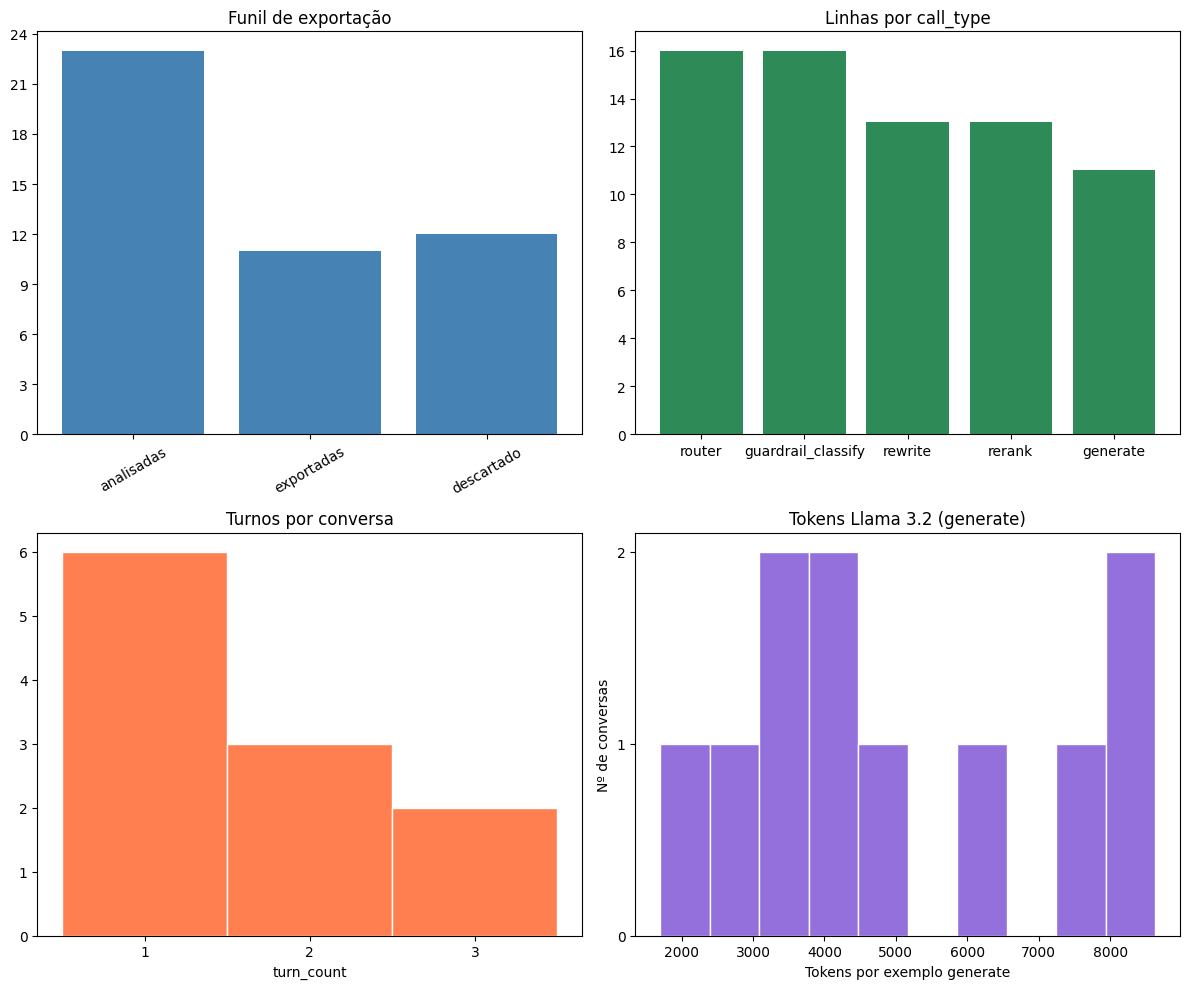

Total turnos (pergunta+resposta): 18 | Tokens: mean=4906 max=8630


In [33]:
# Funil de exportação
reasons = list(funnel.dropped.keys()) + ["exported"]
counts = [funnel.dropped.get(r, 0) for r in funnel.dropped] + [funnel.exported]
if funnel.exported not in funnel.dropped.values():
    reasons = list(funnel.dropped.keys()) + ["exported"]
    counts = list(funnel.dropped.values()) + [funnel.exported]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1) Funil
FUNNEL_LABEL_PT = {
    "scanned": "analisadas",
    "exported": "exportadas",
    "no_positive": "descartado",
    "toxic_before_last_positive": "tóxico antes do último positivo",
    "toxic_final_turn": "turno final tóxico",
    "missing_llm_pair": "sem par LLM",
    "pii_validation_failed": "falha na validação PII",
    "unknown": "desconhecido",
}
ax = axes[0, 0]
funnel_keys = ["scanned", "exported"] + list(funnel.dropped.keys())
labels = [FUNNEL_LABEL_PT.get(k, k) for k in funnel_keys]
vals = [funnel.scanned, funnel.exported] + list(funnel.dropped.values())
ax.bar(labels, vals, color="steelblue")
ax.set_title("Funil de exportação")
ax.tick_params(axis="x", rotation=30)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

# 2) call_type
ax = axes[0, 1]
if len(df_export):
    ct = df_export["call_type"].value_counts()
    ax.bar(ct.index.astype(str), ct.values, color="seagreen")
ax.set_title("Linhas por call_type")

# 3) turn_count (pares pergunta + resposta)
ax = axes[1, 0]
if len(df_conv_stats) >= 2:
    turns = df_conv_stats["turn_count"].astype(int)
    min_t, max_t = int(turns.min()), int(turns.max())
    bins = np.arange(min_t, max_t + 2) - 0.5
    ax.hist(turns, bins=bins, color="coral", edgecolor="white")
elif len(df_conv_stats) == 1:
    ax.bar([str(int(df_conv_stats["turn_count"].iloc[0]))], [1], color="coral")
ax.set_title("Turnos por conversa")
ax.set_xlabel("turn_count")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

# 4) token_count (tamanho do exemplo generate para SFT)
ax = axes[1, 1]
if len(df_conv_stats) >= 2:
    ax.hist(df_conv_stats["token_count"], bins=min(10, len(df_conv_stats)), color="mediumpurple", edgecolor="white")
elif len(df_conv_stats) == 1:
    ax.bar([str(int(df_conv_stats["token_count"].iloc[0]))], [1], color="mediumpurple")
ax.set_title("Tokens Llama 3.2 (generate)")
ax.set_xlabel("Tokens por exemplo generate")
ax.set_ylabel("Nº de conversas")
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

if len(df_conv_stats):
    print(
        f"Total turnos (pergunta+resposta): {int(df_conv_stats['turn_count'].sum())} | "
        f"Tokens: mean={df_conv_stats['token_count'].mean():.0f} max={df_conv_stats['token_count'].max()}"
    )


## Gravar JSONL e validar com `datasets`


In [34]:
REQUIRED_COLS = {
    "conversation_id",
    "patient_id",
    "doctor_id",
    "message_id",
    "call_type",
    "sequence",
    "model",
    "llm_input",
    "llm_output",
}

if df_export.empty:
    print("Nenhum registro para gravar.")
else:
    missing = REQUIRED_COLS - set(df_export.columns)
    assert not missing, f"Colunas ausentes: {missing}"

    df_export.to_json(OUTPUT_PATH, orient="records", lines=True, force_ascii=False)
    print(f"Gravado: {OUTPUT_PATH} ({len(df_export)} linhas)")

    ds = load_dataset("json", data_files=str(OUTPUT_PATH), split="train")
    print(ds)
    ds_generate = ds.filter(lambda row: row["call_type"] == "generate")
    print(f"Exemplos generate para LoRA: {len(ds_generate)}")


Gravado: /Users/leanderseefeld/workspaces/fiap/8iadt-tc-fase3-assistente-medico/llm/fine-tuning/assets/sft_positive_conversations.jsonl (69 linhas)


Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['conversation_id', 'patient_id', 'doctor_id', 'message_id', 'call_type', 'sequence', 'model', 'llm_input', 'llm_output'],
    num_rows: 69
})


Filter:   0%|          | 0/69 [00:00<?, ? examples/s]

Exemplos generate para LoRA: 11


In [35]:
ds_generate[0]['llm_input']

[{'role': 'system',
  'content': 'Você é um assistente clínico de apoio a médicos no Brasil.\nResponda sempre em português do Brasil, de forma objetiva e profissional.\nSeja direto: vá ao ponto sem introduções desnecessárias, e use listas apenas quando genuinamente útil.\nNunca invente dados clínicos; quando recorrer ao conhecimento geral sem respaldo de protocolo, sinalize isso claramente.\nNunca utilize placeholders numéricos, textuais genéricos como "[Nome do Médico]" ou inicie com saudações. Vá direto ao resumo ou à resposta.\nSó cumprimente se o médico cumprimentar primeiro.\n\n## Contexto por turno\nA cada turno você pode receber contexto estruturado pelo sistema: dados clínicos do paciente e/ou resultados de busca em PCDTs (Protocolos Clínicos e Diretrizes Terapêuticas).\nO médico não vê esse contexto diretamente — ele só vê suas próprias mensagens e suas respostas.\nUse o contexto clínico para personalizar a resposta quando aplicável; não extrapole além do que foi fornecido.\nU